## Phase 2 — Exploratory Data Analysis (EDA)

This section explores patterns, trends, and relationships in the cleaned IndiaKart data using charts.
Each chart includes a short written observation.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
files = {
    'orders':      'orders DA.csv',
    'order_items': 'order_items DA.csv',
    'customers':   'customers DA.csv',
    'products':    'products DA.csv',
    'payments':    'payments DA.csv',
    'returns':     'returns DA.csv',
    'inventory':   'inventory DA.csv',
    'suppliers':   'suppliers DA.csv',
}

In [9]:
dfs = {name: pd.read_csv(path) for name, path in files.items()}
orders      = dfs['orders']
order_items = dfs['order_items']
customers   = dfs['customers']
products    = dfs['products']
payments    = dfs['payments']
returns     = dfs['returns']
inventory   = dfs['inventory']
suppliers   = dfs['suppliers']

In [10]:
orders['order_date']     = pd.to_datetime(orders['order_date'], format='%d-%m-%Y')
orders['delivered_date'] = pd.to_datetime(orders['delivered_date'], format='%d-%m-%Y', errors='coerce')

In [11]:
orders.dtypes

order_id                    object
customer_id                 object
order_date          datetime64[ns]
order_time                  object
status                      object
city                        object
state                       object
pincode                      int64
total_amount               float64
gst_amount                 float64
shipping_charge              int64
discount_amount            float64
final_amount               float64
payment_method              object
shipping_partner            object
tracking_id                 object
delivered_date      datetime64[ns]
is_cod                       int64
channel                     object
dtype: object

# Chart 1: Monthly Order Volume

#### extract the month from order date

In [12]:
monthly_orders = orders['order_date'].dt.to_period('M').value_counts().sort_index()
print(monthly_orders)

order_date
2023-06     444
2023-07    2081
2023-08    2091
2023-09    2104
2023-10    2060
2023-11    2114
2023-12    2090
2024-01    2090
2024-02    1907
2024-03    2111
2024-04    2131
2024-05    2167
2024-06    2072
2024-07    2025
2024-08    2146
2024-09    2011
2024-10    2131
2024-11    2084
2024-12    2148
2025-01    2239
2025-02    1879
2025-03    2167
2025-04    2024
2025-05    2134
2025-06    1550
Freq: M, Name: count, dtype: int64


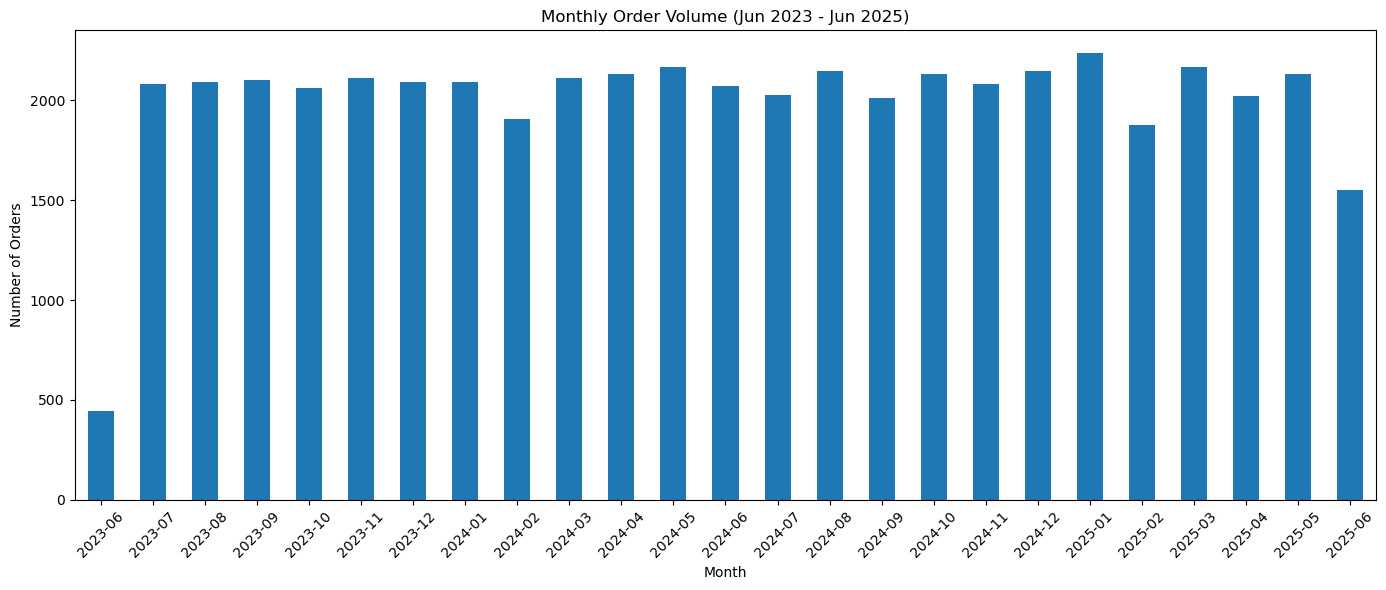

In [13]:
plt.figure(figsize=(14, 6))
monthly_orders.plot(kind='bar')
plt.title('Monthly Order Volume (Jun 2023 - Jun 2025)')
plt.xlabel('Month')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

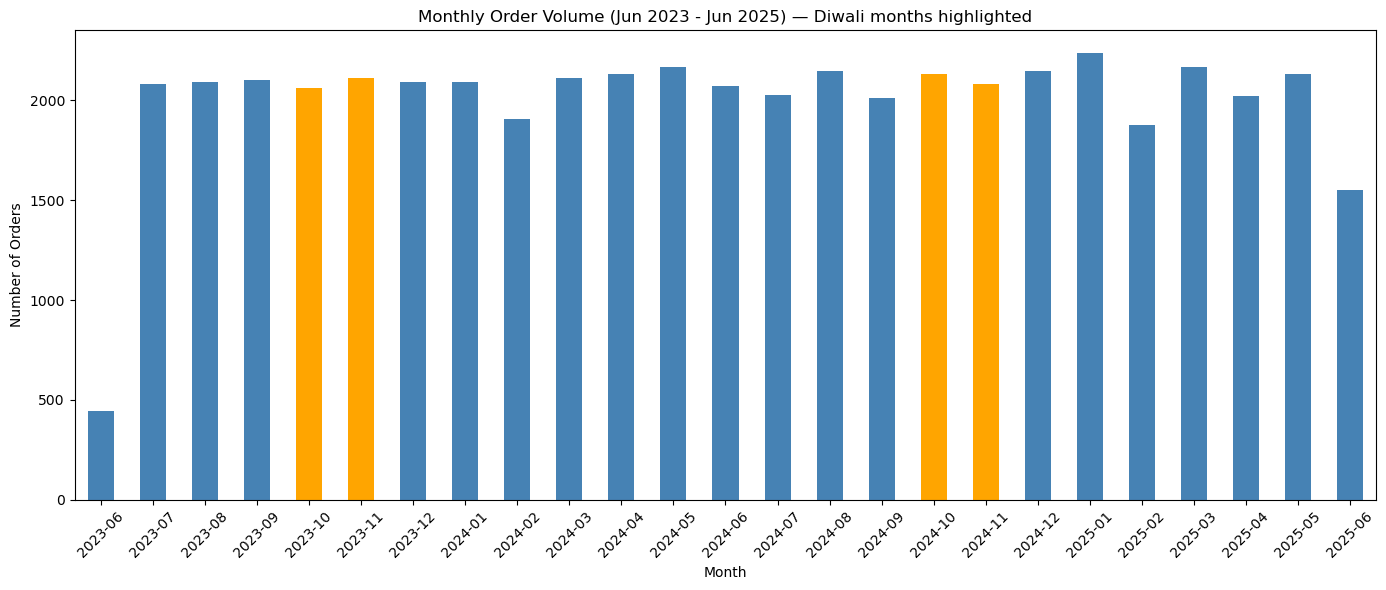

In [14]:
colors = ['orange' if month.month in [10, 11] else 'steelblue' for month in monthly_orders.index]

plt.figure(figsize=(14, 6))
monthly_orders.plot(kind='bar', color=colors)
plt.title('Monthly Order Volume (Jun 2023 - Jun 2025) — Diwali months highlighted')
plt.xlabel('Month')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Monthly Order Volume Observation
There is no noticeable spike in order volume during the Diwali months (October/November) in either
2023 or 2024 — order counts stay in the same 1,900-2,200 range as the rest of the year. The lowest
bars are June 2023 (444 orders) and June 2025 (1,550 orders), but these are partial months since the
dataset starts and ends mid-June, not a real dip in demand. Overall, monthly order volume is fairly
stable across the full 24-month period, without a clear seasonal pattern around the festive season.

# Chart 2: Monthly Revenue (GMV)

In [15]:
monthly_revenue = orders.groupby(orders['order_date'].dt.to_period('M'))['final_amount'].sum()
print(monthly_revenue)

order_date
2023-06    2.738485e+07
2023-07    1.289205e+08
2023-08    1.281220e+08
2023-09    1.374625e+08
2023-10    1.324709e+08
2023-11    1.372634e+08
2023-12    1.369234e+08
2024-01    1.314500e+08
2024-02    1.209459e+08
2024-03    1.336701e+08
2024-04    1.315097e+08
2024-05    1.363584e+08
2024-06    1.237410e+08
2024-07    1.270283e+08
2024-08    1.319235e+08
2024-09    1.305253e+08
2024-10    1.335183e+08
2024-11    1.262641e+08
2024-12    1.330895e+08
2025-01    1.379291e+08
2025-02    1.141167e+08
2025-03    1.364932e+08
2025-04    1.308222e+08
2025-05    1.358494e+08
2025-06    1.036033e+08
Freq: M, Name: final_amount, dtype: float64


In [16]:
pd.options.display.float_format = '{:,.0f}'.format
print(monthly_revenue)

order_date
2023-06    27,384,849
2023-07   128,920,509
2023-08   128,122,037
2023-09   137,462,483
2023-10   132,470,874
2023-11   137,263,359
2023-12   136,923,402
2024-01   131,450,025
2024-02   120,945,866
2024-03   133,670,054
2024-04   131,509,731
2024-05   136,358,367
2024-06   123,740,980
2024-07   127,028,266
2024-08   131,923,460
2024-09   130,525,274
2024-10   133,518,341
2024-11   126,264,142
2024-12   133,089,460
2025-01   137,929,117
2025-02   114,116,741
2025-03   136,493,234
2025-04   130,822,234
2025-05   135,849,393
2025-06   103,603,348
Freq: M, Name: final_amount, dtype: float64


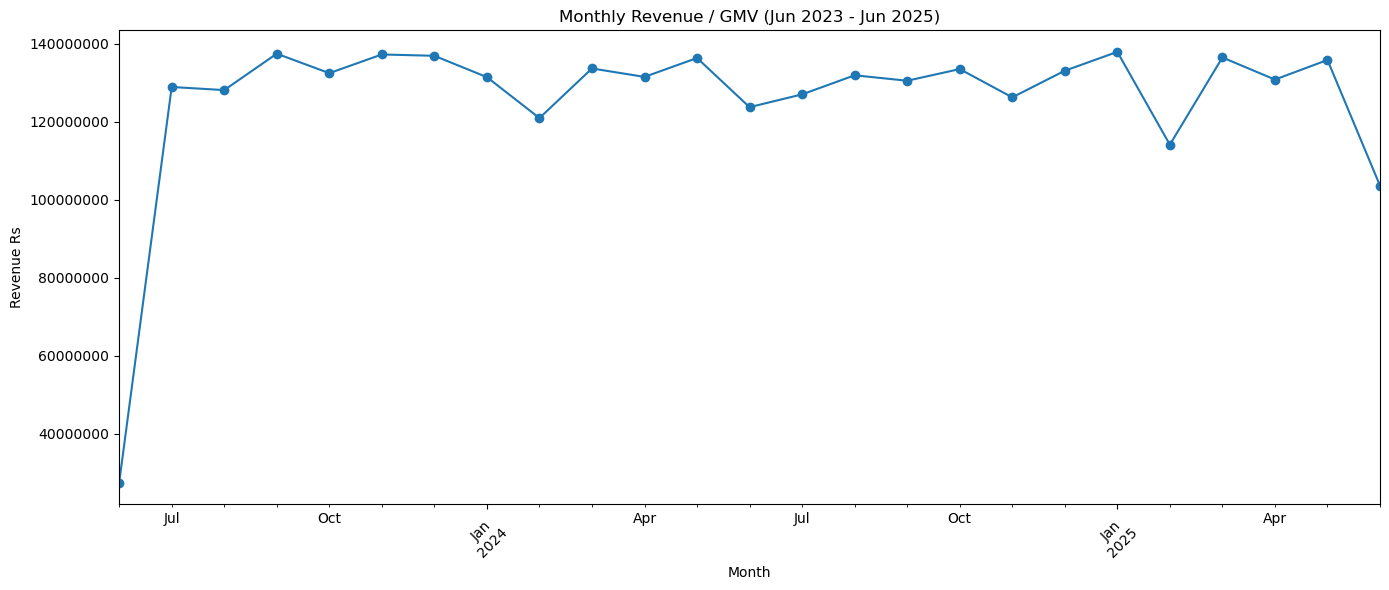

In [18]:
plt.figure(figsize=(14, 6))
monthly_revenue.plot(kind='line', marker='o')
plt.title('Monthly Revenue / GMV (Jun 2023 - Jun 2025)')
plt.xlabel('Month')
plt.ylabel('Revenue Rs')
plt.ticklabel_format(style='plain', axis='y')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Lets group by year and month separately, then reshape into a table

In [19]:
orders['year'] = orders['order_date'].dt.year
orders['month'] = orders['order_date'].dt.month

yoy_revenue = orders.groupby(['year', 'month'])['final_amount'].sum().unstack(level=0)
print(yoy_revenue)

year         2023        2024        2025
month                                    
1             NaN 131,450,025 137,929,117
2             NaN 120,945,866 114,116,741
3             NaN 133,670,054 136,493,234
4             NaN 131,509,731 130,822,234
5             NaN 136,358,367 135,849,393
6      27,384,849 123,740,980 103,603,348
7     128,920,509 127,028,266         NaN
8     128,122,037 131,923,460         NaN
9     137,462,483 130,525,274         NaN
10    132,470,874 133,518,341         NaN
11    137,263,359 126,264,142         NaN
12    136,923,402 133,089,460         NaN


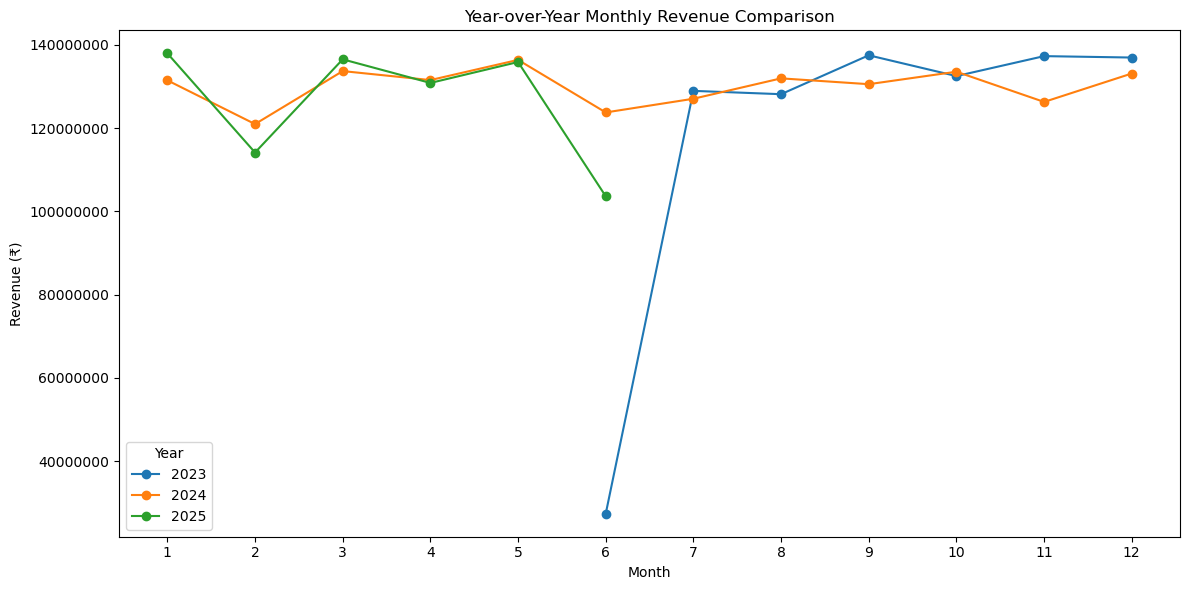

In [21]:
plt.figure(figsize=(12, 6))
yoy_revenue.plot(marker='o', ax=plt.gca())
plt.title('Year-over-Year Monthly Revenue Comparison')
plt.xlabel('Month')
plt.ylabel('Revenue (₹)')
plt.ticklabel_format(style='plain', axis='y')
plt.xticks(range(1, 13))
plt.legend(title='Year')
plt.tight_layout()
plt.show()

### Monthly Revenue Observation:
- Monthly revenue stays pretty flat the whole way through — mostly ₹120-140 million a month,
  no big spikes, no crashes.

- 2024 is the best year to judge by since it's the only one with all 12 months of data, and it
  barely moves — honestly expected a bit more seasonal swing than this.

- 2023 and 2025 track almost right on top of 2024 for the months they share, so there's no real
  sign the business is growing or shrinking year over year in this dataset.

- The dip at the very start (June 2023) and very end (June 2025) isn't a sales drop — those are
  just partial months since the data starts and ends mid-month. Not a real trend, just how the
  dataset is cut off.

# Chart 3: Category-wise Revenue Share

In [22]:
category_revenue = order_items.groupby('category')['total_price'].sum().sort_values(ascending=False)
print(category_revenue)

category
Electronics        1,642,422,813
Sports & Fitness     497,238,435
Home & Kitchen       244,295,160
Fashion              148,155,307
Automotive           123,485,088
Office Supplies       93,029,351
Toys & Baby           46,583,850
Beauty & Health       33,018,106
Grocery               18,718,681
Books                 13,945,894
Name: total_price, dtype: float64


In [26]:
category_share = category_revenue / category_revenue.sum() * 100
print(category_share)

category
Electronics        57
Sports & Fitness   17
Home & Kitchen      9
Fashion             5
Automotive          4
Office Supplies     3
Toys & Baby         2
Beauty & Health     1
Grocery             1
Books               0
Name: total_price, dtype: float64


### horizontal bar 

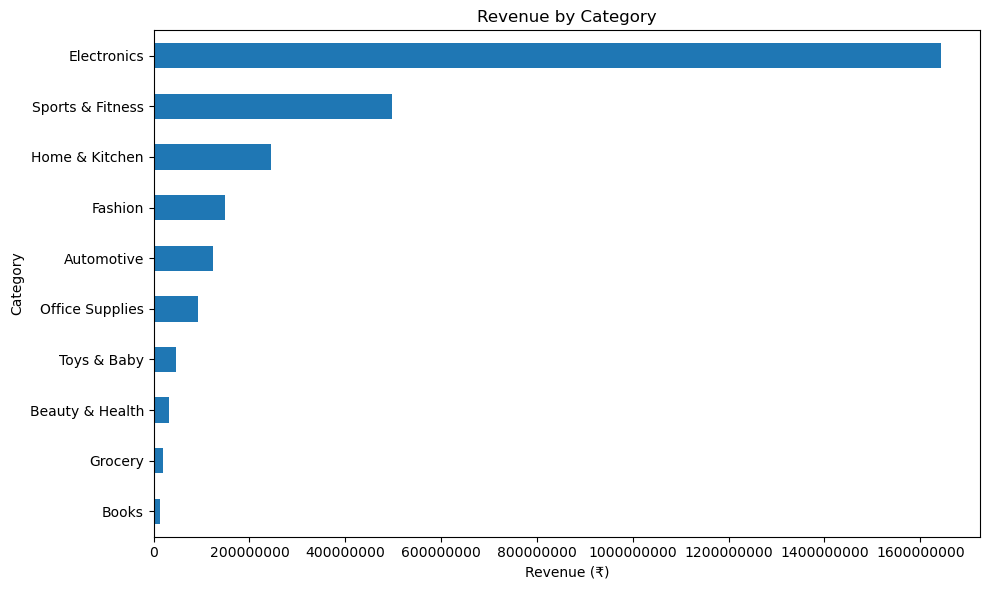

In [27]:
plt.figure(figsize=(10, 6))
category_revenue.sort_values().plot(kind='barh')
plt.title('Revenue by Category')
plt.xlabel('Revenue (₹)')
plt.ylabel('Category')
plt.ticklabel_format(style='plain', axis='x')
plt.tight_layout()
plt.show()

### pie chart

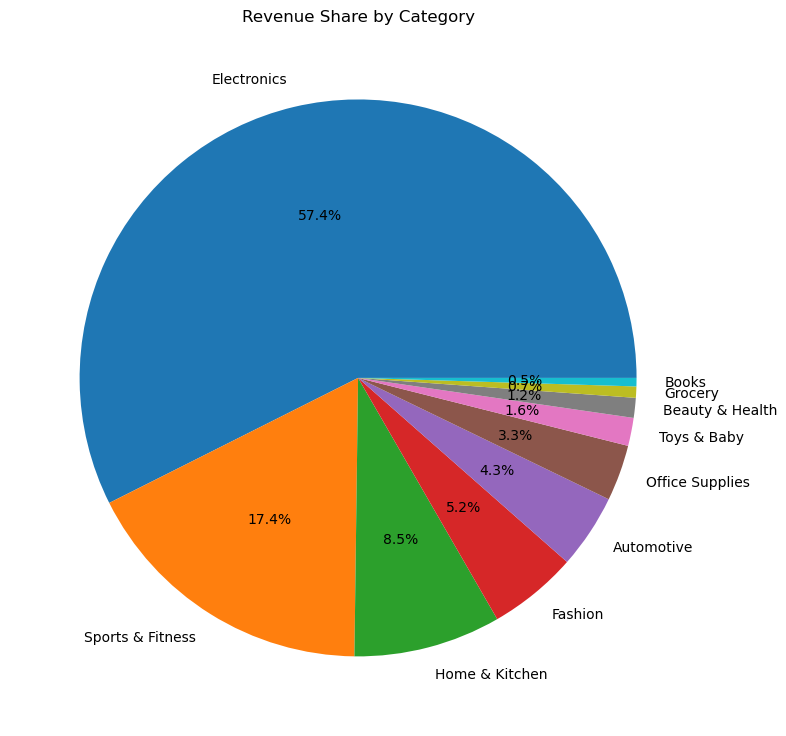

In [28]:
plt.figure(figsize=(8, 8))
category_revenue.plot(kind='pie', autopct='%1.1f%%')
plt.title('Revenue Share by Category')
plt.ylabel('')
plt.tight_layout()
plt.show()

### Category Revenue Observation

- Electronics is way out in front — it makes up 57.4% of total revenue, more than 3x the next
  biggest category (Sports & Fitness at 17.4%). Nothing else really comes close.

- That 57.4% is just under the 60% concentration-risk line the PRD flagged, but it's close enough
  that I'd still call it out as a real risk — if Electronics demand ever dipped, there's no other
  category big enough to absorb the hit.

- The bottom half of the list (Toys & Baby, Beauty & Health, Grocery, Books) barely register —
  each is under 2% of revenue on its own.

- Went with the horizontal bar chart over the pie chart for the final notebook — with numbers
  this skewed, the pie chart's smaller slices get cramped and the labels overlap, while the bar
  chart keeps every category clearly readable regardless of size.

# Chart 4: Order Status Distribution (donut chart)

In [29]:
status_counts = orders['status'].value_counts()
print(status_counts)

status
Delivered     32499
Cancelled      5996
Shipped        5071
Returned       3933
Processing     2501
Name: count, dtype: int64


In [30]:
status_pct = orders['status'].value_counts(normalize=True) * 100
print(status_pct)

status
Delivered    65
Cancelled    12
Shipped      10
Returned      8
Processing    5
Name: proportion, dtype: float64


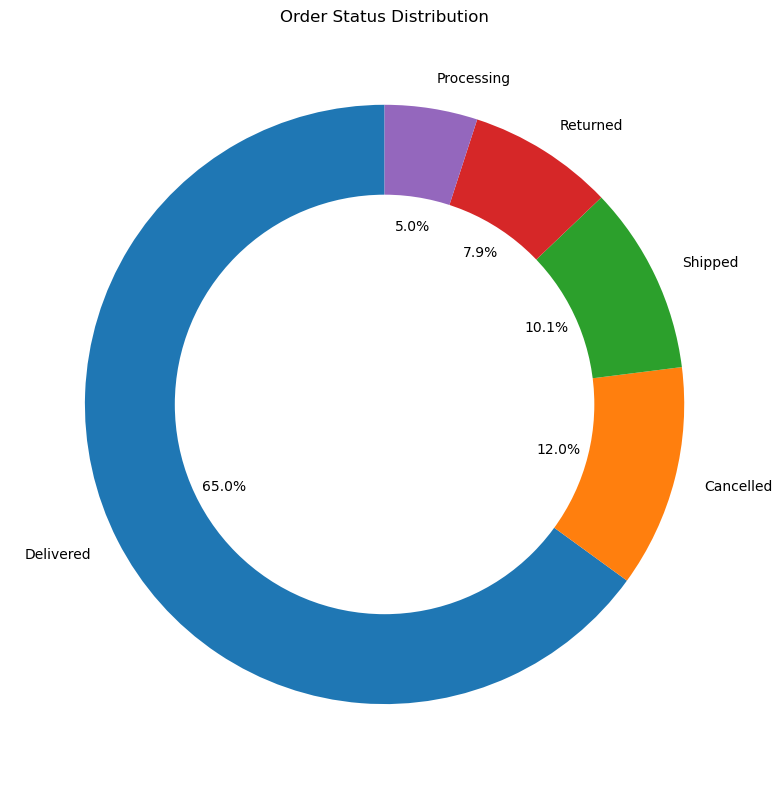

In [33]:
plt.figure(figsize=(8, 8))
plt.pie(status_counts, labels=status_counts.index, autopct='%1.1f%%', startangle=90)
# draw a white circle in the center to create the "donut hole"
center_circle = plt.Circle((0, 0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(center_circle)

plt.title('Order Status Distribution')
plt.tight_layout()
plt.show()



### order Status observation
- Two-thirds of orders (65%) actually make it to Delivered — the rest is split across
  Cancelled, Shipped, Returned, and Processing.

- Cancellation rate comes out to 12%, which misses the target of under 10% set in the PRD.
  That's not a huge miss, but it's real — roughly 1 in every 8 orders placed ends up
  cancelled, which is straight-up lost revenue.

- Returned sits at 7.9%, which is worth keeping an eye on too, especially once we get to
  looking at return reasons later in this phase — right now it's just a number, but it'll
  mean more once we know why people are returning things.

- Shipped (10.1%) and Processing (5%) are basically orders still "in flight" — not finished
  yet, so not necessarily a problem on their own, just a snapshot of where things stand.

# Chart 5: Top 10 States by Number of Orders

In [37]:
states_counts = orders['state'].value_counts()
print(states_counts)

state
Uttar Pradesh      9507
Maharashtra        8179
Gujarat            3811
Madhya Pradesh     3741
Tamil Nadu         3664
Karnataka          3102
Rajasthan          3047
West Bengal        2103
Punjab             2073
Jharkhand          2044
Andhra Pradesh     1803
Chhattisgarh       1102
Delhi              1046
Assam              1027
Chandigarh          966
Jammu & Kashmir     956
Telangana           927
Haryana             902
Name: count, dtype: int64


In [38]:
top_10_states = orders['state'].value_counts().head(10)
print(top_10_states)

state
Uttar Pradesh     9507
Maharashtra       8179
Gujarat           3811
Madhya Pradesh    3741
Tamil Nadu        3664
Karnataka         3102
Rajasthan         3047
West Bengal       2103
Punjab            2073
Jharkhand         2044
Name: count, dtype: int64


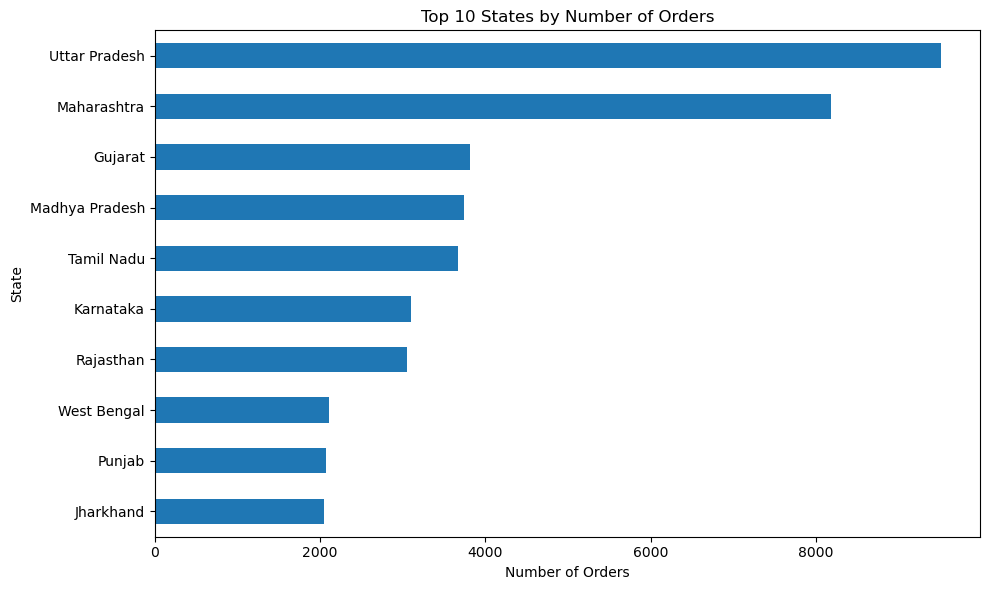

In [39]:
plt.figure(figsize=(10, 6))
top_10_states.sort_values().plot(kind='barh')
plt.title('Top 10 States by Number of Orders')
plt.xlabel('Number of Orders')
plt.ylabel('State')
plt.tight_layout()
plt.show()

### State Order Observation
- Uttar Pradesh and Maharashtra are way out in front — 9,507 and 8,179 orders respectively,
  clearly ahead of everyone else. Makes sense honestly, they're two of India's most populous
  states and both have major commercial cities (UP has a huge population base, Maharashtra
  has Mumbai/Pune), so more people + more urban buyers naturally means more orders.

- After those two, it's a much smoother drop-off — Gujarat, Madhya Pradesh, Tamil Nadu, and
  Karnataka all sit fairly close together in the 3,000-3,800 range, no big cliffs between them.

- By the time you get to West Bengal, Punjab, and Jharkhand near the bottom of the top 10,
  they're roughly a quarter of UP's order count — still solid markets, just nowhere near the
  scale of the top two.

- Worth remembering this is order count, not revenue — a state could have a lot of orders but
  lower average order value, so this chart alone doesn't tell the full "biggest market" story
  on its own.

# Chart 6: Customer Segment Distribution

In [40]:
customers.dtypes

customer_id           object
first_name            object
last_name             object
email                 object
phone                  int64
city                  object
state                 object
pincode                int64
gender                object
age                    int64
segment               object
registration_date     object
last_login_date       object
is_verified            int64
is_active              int64
total_orders           int64
total_spent          float64
dtype: object

In [41]:
segment_counts = customers['segment'].value_counts()
print(segment_counts)

segment
Regular     4026
Budget      2505
Premium     1501
New         1488
Inactive     480
Name: count, dtype: int64


In [42]:
segment_pct = customers['segment'].value_counts(normalize=True) * 100
print(segment_pct)

segment
Regular    40
Budget     25
Premium    15
New        15
Inactive    5
Name: proportion, dtype: float64


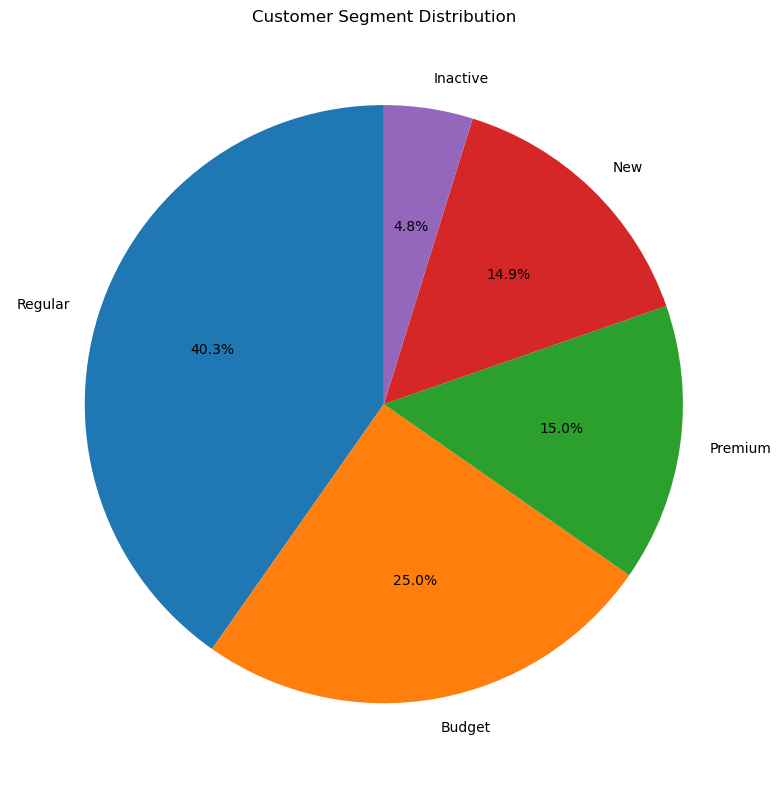

In [43]:
plt.figure(figsize=(8, 8))
plt.pie(segment_counts, labels=segment_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Customer Segment Distribution')
plt.tight_layout()
plt.show()

### Observation 
- Regular customers are the biggest single group at 40.3% — makes sense, that's usually the
  "default" bucket most people land in before they either upgrade to Premium or drop off.

- Premium is actually the smallest of the three named segments — just 15.0%, behind both
  Regular (40.3%) and Budget (25.0%). That's a bit surprising and worth flagging: if Premium
  customers are supposed to be the most valuable (the PRD mentions they should spend ~3x what
  Regular customers do), having them be the smallest group means the business's highest-value
  customers are a pretty thin slice of the total base. Something to dig into more once we get
  to CLV numbers in Phase 3.

- New (14.9%) and Inactive (4.8%) make up the rest — together that's a decent chunk of
  customers (almost 20%) who either haven't built a habit yet or have gone quiet, which feels
  like a real opportunity for the business to try and convert or win back.

# Chart 7: Payment Method Usage

In [46]:
payment_method = orders['payment_method'].value_counts()
print(payment_method)

payment_method
UPI                 17570
Credit Card         10007
Debit Card           7624
Cash on Delivery     5883
Net Banking          4026
EMI                  2943
Wallet               1947
Name: count, dtype: int64


In [67]:
payment_pct = orders['payment_method'].value_counts(normalize=True) * 100
print(payment_pct)

payment_method
UPI                35
Credit Card        20
Debit Card         15
Cash on Delivery   12
Net Banking         8
EMI                 6
Wallet              4
Name: proportion, dtype: float64


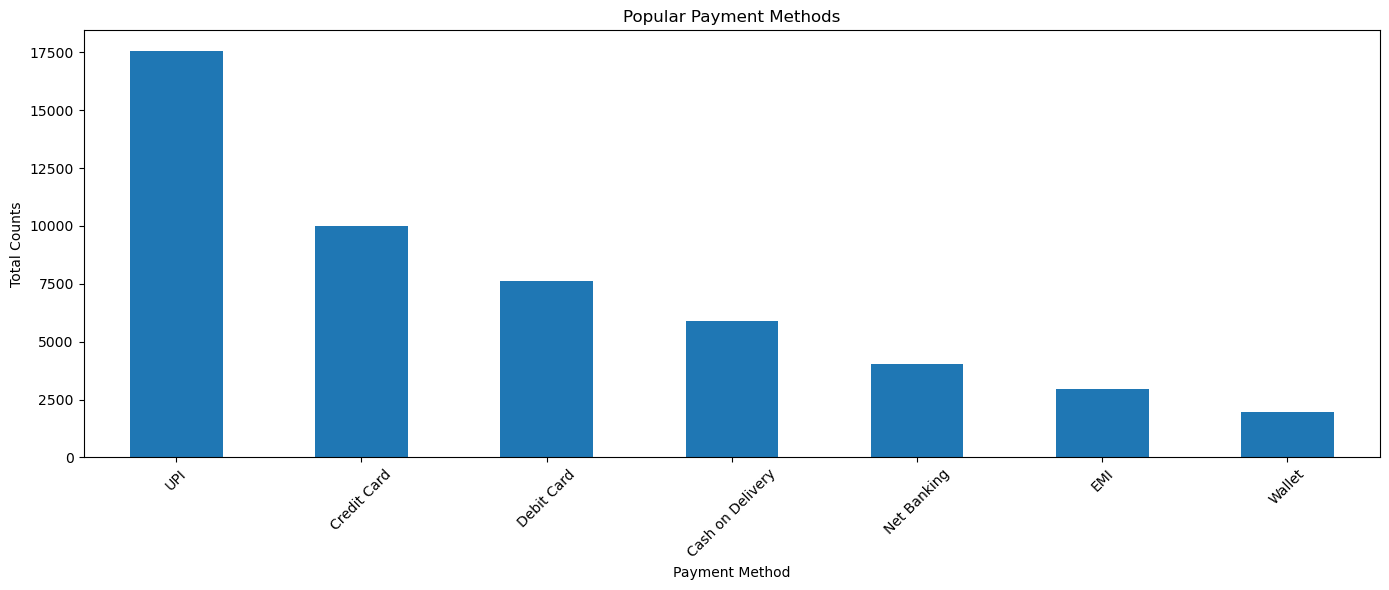

In [49]:
plt.figure(figsize=(14, 6))
payment_method.plot(kind='bar')
plt.title('Popular Payment Methods')
plt.xlabel('Payment Method')
plt.ylabel('Total Counts')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### observation
- UPI is the clear favorite — 17,570 orders paid this way, way ahead of Credit Card at
  10,807. It's not even close, UPI alone accounts for more than a third of all orders.

- Makes sense honestly — UPI's free, instant, and basically everyone in India has it on
  their phone at this point. No card details to type in, no fees, just scan and pay. Given
  how easy it is, it's not surprising it beats every other method by this much.

- Cash on Delivery is still around (5,883 orders) but it's sitting in the middle of the
  pack, not dominant like it probably would've been a few years ago. Digital payments
  (UPI + Credit + Debit combined) clearly outnumber COD by a lot here.

- Wallet and EMI are the least used — makes sense, those are more niche/specific use cases
  (EMI usually only makes sense for bigger purchases, wallets have mostly been overtaken
  by UPI anyway).

# Chart 8: Age Distribution of Customers

In [50]:
customers['age'].describe()

count   10,000
mean        42
std         14
min         18
25%         30
50%         42
75%         54
max         65
Name: age, dtype: float64

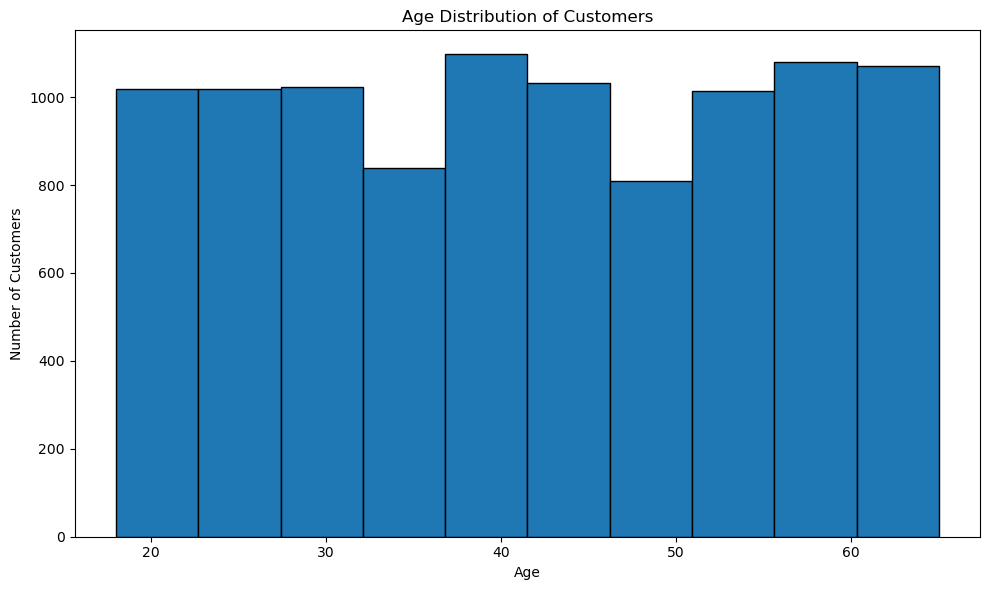

In [51]:
plt.figure(figsize=(10, 6))
plt.hist(customers['age'], bins=10, edgecolor='black')
plt.title('Age Distribution of Customers')
plt.xlabel('Age')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.show()

### observation
- The age distribution is basically flat — every bucket has somewhere between 800 and 1,100
  customers, no age group really stands out. Customers range from 18 to 65, with the average
  sitting right around 42.

- If anything, there are slight bumps around the late 30s and late 50s, but honestly the
  difference between the tallest and shortest bars is small enough that I wouldn't call it a
  real pattern — it's close to an even spread across the board.

- This actually says something useful for the business: IndiaKart isn't skewing toward one
  generation (like being a "young shopper" or "older shopper" platform) — it's pulling
  customers fairly evenly across working-age adults. Marketing probably doesn't need to be
  age-targeted here, broad campaigns likely work fine since no single age bracket dominates
  the customer base.

# Chart 9: Return Reasons

a bar chart of the most common return reasons

In [52]:
returns.dtypes

return_id            object
order_id             object
customer_id          object
return_date          object
reason               object
return_amount       float64
refund_status        object
refund_date          object
return_condition     object
remarks              object
dtype: object

In [53]:
returns_reasons = returns['reason'].value_counts()
print(returns_reasons)

reason
Size Issue                 1196
Changed Mind               1150
Damaged in Transit         1143
Wrong Product Delivered    1135
Defective Product          1134
Not as Described           1125
Duplicate Order            1081
Quality Issue              1075
Delayed Delivery            484
Better Price Found          477
Name: count, dtype: int64


In [55]:
returns_pct = returns['reason'].value_counts(normalize=True) * 100
print(returns_pct)

reason
Size Issue                12
Changed Mind              12
Damaged in Transit        11
Wrong Product Delivered   11
Defective Product         11
Not as Described          11
Duplicate Order           11
Quality Issue             11
Delayed Delivery           5
Better Price Found         5
Name: proportion, dtype: float64


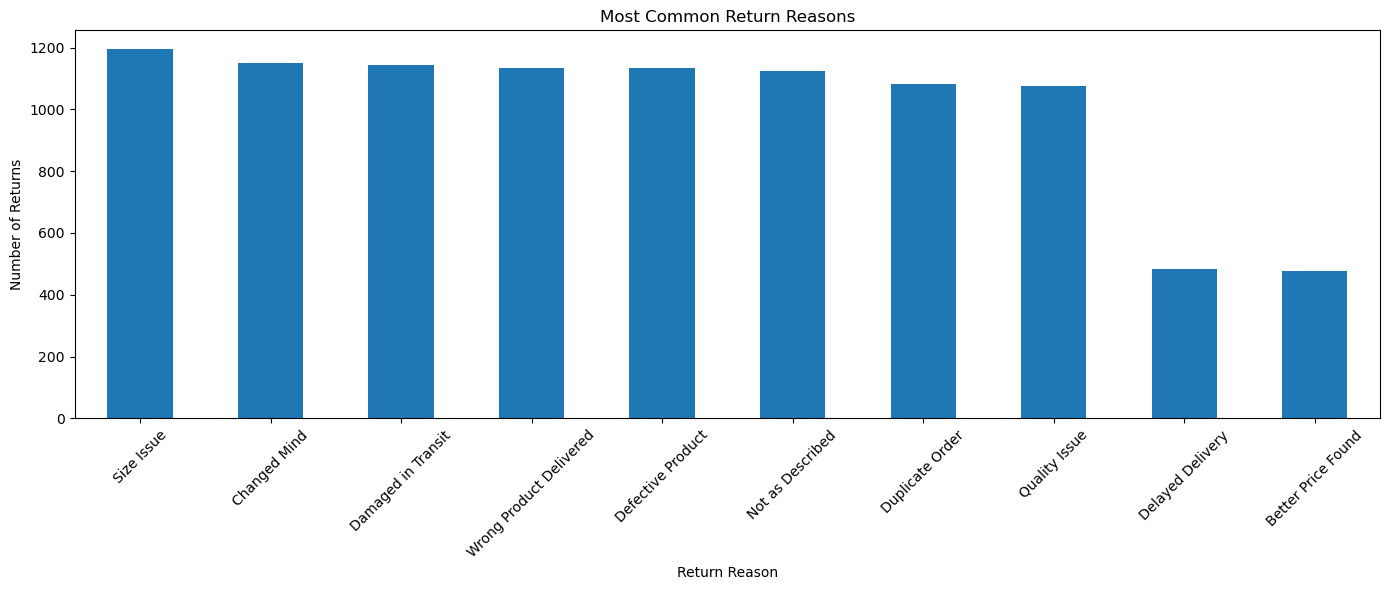

In [57]:
plt.figure(figsize=(14, 6))
returns_reasons.plot(kind='bar')
plt.title('Most Common Return Reasons')
plt.xlabel('Return Reason')
plt.ylabel('Number of Returns')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### observation
- Return reasons don't really have one dominant cause — the top 8 reasons are all bunched
  together in the 1,000-1,200 range, no single one stands out as "the" problem to fix.

- Size Issue is technically the top reason (1,196), but it's barely ahead of Quality Issue at
  the bottom of that cluster (1,075) — only about a 10% gap between the most and least common
  reason in that group of 8.

- Delayed Delivery (484) and Better Price Found (477) are clearly the least common reasons —
  less than half the volume of everything else. So logistics delays and price-shopping aren't
  really driving returns here, which is a bit of good news.

- Worth noting there's a mix of causes in that top cluster — some are about the product itself
  (Defective Product, Quality Issue, Damaged in Transit), some are fulfillment mistakes (Wrong
  Product Delivered, Duplicate Order), and some are just customer preference (Size Issue,
  Changed Mind, Not as Described). That spread means there's no single fix — quality control,
  warehouse accuracy, and product listings (sizing info, photos, descriptions) would all need
  attention to meaningfully bring returns down.

# Chart 10: Average Order Value (AOV) by Segment

AOV is defined as Net Revenue ÷ Delivered Orders

In [59]:
delivered_orders = orders[orders['status'] == 'Delivered'] # filter to only Delivered orders

In [60]:
merged = pd.merge(delivered_orders, customers[['customer_id', 'segment']], on='customer_id', how='left') # merge with customers to bring in the segment column

In [61]:
aov_by_segment = merged.groupby('segment')['final_amount'].mean().sort_values(ascending=False) #group by segment, average final_amount

In [62]:
aov_by_segment

segment
Budget     64,951
Inactive   63,639
Regular    63,458
New        63,278
Premium    61,692
Name: final_amount, dtype: float64

In [63]:
customers.groupby('segment')[['total_orders', 'total_spent']].mean()

,total_orders,total_spent
segment,,
Budget,3,"186,179"
Inactive,1,"32,249"
New,4,"274,866"
Premium,9,"532,735"
Regular,6,"361,871"


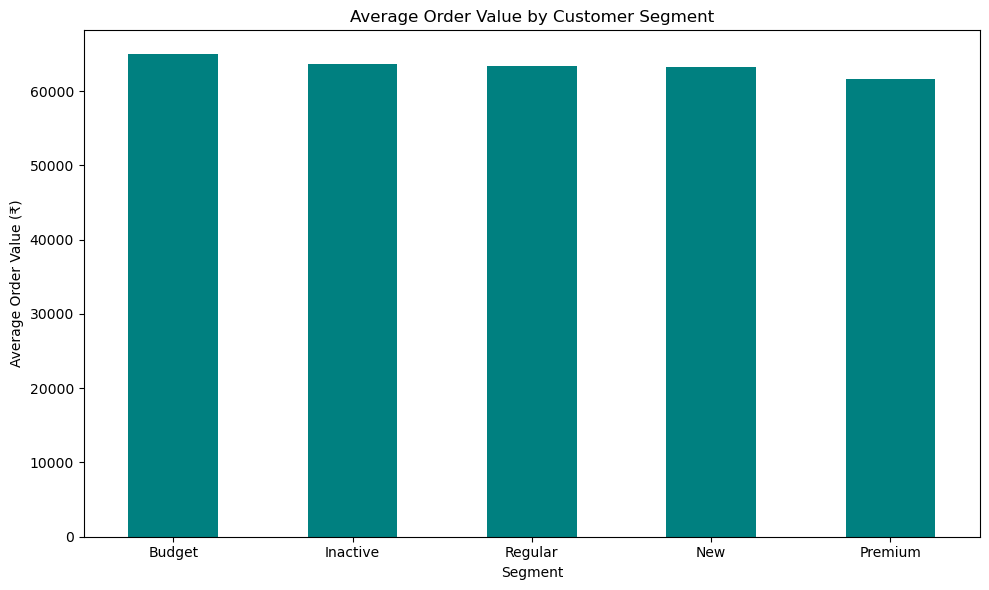

In [64]:
plt.figure(figsize=(10, 6))
aov_by_segment.plot(kind='bar', color='teal')
plt.title('Average Order Value by Customer Segment')
plt.xlabel('Segment')
plt.ylabel('Average Order Value (₹)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### observation 
- Looking at AOV alone, the segments are surprisingly close — Budget actually has the highest
  average order value (₹64,951), while Premium has the lowest (₹61,692). At first glance that
  looks backwards, like Premium customers aren't really "premium" at all.

- But AOV alone is misleading here. Checking total_orders and total_spent per segment tells the
  real story: Premium customers place way more orders on average (9 vs Budget's 3) and their
  lifetime spend is nearly 3x Regular and almost 3x Budget (₹5,32,735 vs ₹1,86,179). They're just
  spreading that spend across more, smaller orders instead of fewer big ones.

- So the honest answer to "do Premium customers spend more?" is yes — just not per individual
  order. It shows up in how often they buy, not how much they spend each time. If we'd only
  looked at AOV and stopped there, we'd have drawn the wrong conclusion about who the most
  valuable customers actually are.

- Worth carrying this forward into Phase 3 — CLV (lifetime spend) is the metric that actually
  reflects segment value here, AOV on its own doesn't tell the full picture.